<a href="https://colab.research.google.com/github/Satishpk15/Python/blob/main/B2_Sql.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import sqlite3
import seaborn as sns

# Create database
conn = sqlite3.connect('joins_practice.db')

# Create sample tables
students = pd.DataFrame({
    'student_id': [1, 2, 3, 4, 5],
    'name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'class_id': [101, 102, 101, None, 103]
})

classes = pd.DataFrame({
    'class_id': [101, 102, 104],
    'class_name': ['Math', 'Science', 'History'],
    'teacher': ['Mr. Smith', 'Ms. Johnson', 'Mr. Brown']
})

grades = pd.DataFrame({
    'student_id': [1, 2, 3, 6],
    'subject': ['Math', 'Science', 'Math', 'English'],
    'grade': ['A', 'B', 'A', 'C']
})

# Save to database
students.to_sql('students', conn, if_exists='replace', index=False)
classes.to_sql('classes', conn, if_exists='replace', index=False)
grades.to_sql('grades', conn, if_exists='replace', index=False)

print("Sample tables created!")
print(f"Students: {len(students)} rows")
print(f"Classes: {len(classes)} rows")
print(f"Grades: {len(grades)} rows")

conn.close()

Sample tables created!
Students: 5 rows
Classes: 3 rows
Grades: 4 rows


In [ ]:
students

,student_id,name,class_id
0,1,Alice,101.0
1,2,Bob,102.0
2,3,Charlie,101.0
3,4,Diana,NaN
4,5,Eve,103.0


In [ ]:
classes

,class_id,class_name,teacher
0,101,Math,Mr. Smith
1,102,Science,Ms. Johnson
2,104,History,Mr. Brown


In [ ]:
grades

,student_id,subject,grade
0,1,Math,A
1,2,Science,B
2,3,Math,A
3,6,English,C


In [ ]:
print(101.0==101)

True


In [ ]:
inner_join = '''SELECT * FROM students INNER JOIN classes ON
students.class_id = classes.class_id'''

conn = sqlite3.connect('joins_practice.db')

df_sql = pd.read_sql(inner_join, conn)
df_sql

,student_id,name,class_id,class_id,class_name,teacher
0,1,Alice,101.0,101,Math,Mr. Smith
1,2,Bob,102.0,102,Science,Ms. Johnson
2,3,Charlie,101.0,101,Math,Mr. Smith


In [ ]:
inner_join = '''SELECT students.student_id,
 students.name,
 students.class_id,
 class_name, teacher
 FROM students INNER JOIN classes ON
students.class_id = classes.class_id'''

conn = sqlite3.connect('joins_practice.db')

df_sql = pd.read_sql(inner_join, conn)
df_sql

,student_id,name,class_id,class_name,teacher
0,1,Alice,101.0,Math,Mr. Smith
1,2,Bob,102.0,Science,Ms. Johnson
2,3,Charlie,101.0,Math,Mr. Smith


In [ ]:
inner_join = '''SELECT
 s.student_id,
 s.name,
 s.class_id,
 c.class_name,
 c.teacher
 FROM students as s INNER JOIN classes as c ON
 s.class_id = c.class_id'''

conn = sqlite3.connect('joins_practice.db')

df_sql = pd.read_sql(inner_join, conn)
df_sql

,student_id,name,class_id,class_name,teacher
0,1,Alice,101.0,Math,Mr. Smith
1,2,Bob,102.0,Science,Ms. Johnson
2,3,Charlie,101.0,Math,Mr. Smith


In [ ]:
result = pd.merge(students, classes,
                  on = 'class_id',
                  how='inner')
result

,student_id,name,class_id,class_name,teacher
0,1,Alice,101.0,Math,Mr. Smith
1,2,Bob,102.0,Science,Ms. Johnson
2,3,Charlie,101.0,Math,Mr. Smith


In [ ]:
inner_join = '''SELECT
 s.student_id,
 s.name,
 s.class_id,
 c.class_name,
 c.teacher
 FROM classes as c INNER JOIN students as s ON
 s.class_id = c.class_id'''

conn = sqlite3.connect('joins_practice.db')

df_sql = pd.read_sql(inner_join, conn)
df_sql

,student_id,name,class_id,class_name,teacher
0,1,Alice,101.0,Math,Mr. Smith
1,3,Charlie,101.0,Math,Mr. Smith
2,2,Bob,102.0,Science,Ms. Johnson


In [ ]:
grades


,student_id,subject,grade
0,1,Math,A
1,2,Science,B
2,3,Math,A
3,6,English,C


In [ ]:
inner_join = '''SELECT
 s.student_id,
 s.name,
 s.class_id,
 c.class_name,
 c.teacher,
 g.subject,
 g.grade
 FROM classes as c INNER JOIN students as s ON
 s.class_id = c.class_id
 INNER JOIN grades as g ON s.student_id = g.student_id
 '''

conn = sqlite3.connect('joins_practice.db')

df_sql = pd.read_sql(inner_join, conn)
df_sql

,student_id,name,class_id,class_name,teacher,subject,grade
0,1,Alice,101.0,Math,Mr. Smith,Math,A
1,3,Charlie,101.0,Math,Mr. Smith,Math,A
2,2,Bob,102.0,Science,Ms. Johnson,Science,B


In [ ]:
df_sql.to_excel("temp.xlsx")

In [ ]:
left_query = '''SELECT
    *
FROM students
LEFT JOIN classes
ON students.class_id = classes.class_id;'''


df_sql = pd.read_sql(left_query, conn)
df_sql

,student_id,name,class_id,class_id,class_name,teacher
0,1,Alice,101.0,101.0,Math,Mr. Smith
1,2,Bob,102.0,102.0,Science,Ms. Johnson
2,3,Charlie,101.0,101.0,Math,Mr. Smith
3,4,Diana,NaN,NaN,None,None
4,5,Eve,103.0,NaN,None,None


In [ ]:
left_query = '''SELECT
    *
FROM classes
LEFT JOIN students
ON students.class_id = classes.class_id;'''


df_sql = pd.read_sql(left_query, conn)
df_sql

,class_id,class_name,teacher,student_id,name,class_id
0,101,Math,Mr. Smith,1.0,Alice,101.0
1,101,Math,Mr. Smith,3.0,Charlie,101.0
2,102,Science,Ms. Johnson,2.0,Bob,102.0
3,104,History,Mr. Brown,NaN,None,NaN


In [ ]:
left_query = '''SELECT
    *
FROM classes
LEFT JOIN students
ON students.class_id = classes.class_id;'''


df_sql = pd.read_sql(left_query, conn)
df_sql

,class_id,class_name,teacher,student_id,name,class_id
0,101,Math,Mr. Smith,1.0,Alice,101.0
1,101,Math,Mr. Smith,3.0,Charlie,101.0
2,102,Science,Ms. Johnson,2.0,Bob,102.0
3,104,History,Mr. Brown,NaN,None,NaN


In [ ]:
left_query = '''SELECT
    *
FROM classes
RIGHT JOIN students
ON students.class_id = classes.class_id;'''


df_sql = pd.read_sql(left_query, conn)
df_sql

DatabaseError: Execution failed on sql 'SELECT 
    *
FROM classes
RIGHT JOIN students
ON students.class_id = classes.class_id;': RIGHT and FULL OUTER JOINs are not currently supported

In [ ]:
result = pd.merge(
    students,
    classes,
    on='class_id',
    how='right'
)
result

,student_id,name,class_id,class_name,teacher
0,1.0,Alice,101.0,Math,Mr. Smith
1,3.0,Charlie,101.0,Math,Mr. Smith
2,2.0,Bob,102.0,Science,Ms. Johnson
3,NaN,NaN,104.0,History,Mr. Brown


In [ ]:
pd.merge(result, table3, on = "", how = "")

In [ ]:
result = pd.merge(
    classes,
    students,
    on='class_id',
    how='left'
)
result

,class_id,class_name,teacher,student_id,name
0,101,Math,Mr. Smith,1.0,Alice
1,101,Math,Mr. Smith,3.0,Charlie
2,102,Science,Ms. Johnson,2.0,Bob
3,104,History,Mr. Brown,NaN,NaN


In [ ]:
result = pd.merge(
    students,
    classes,
    on='class_id',
    how='left'
)
result

,student_id,name,class_id,class_name,teacher
0,1,Alice,101.0,Math,Mr. Smith
1,2,Bob,102.0,Science,Ms. Johnson
2,3,Charlie,101.0,Math,Mr. Smith
3,4,Diana,NaN,NaN,NaN
4,5,Eve,103.0,NaN,NaN


# Download the db from this git -
https://github.com/lerocha/chinook-database/tree/master

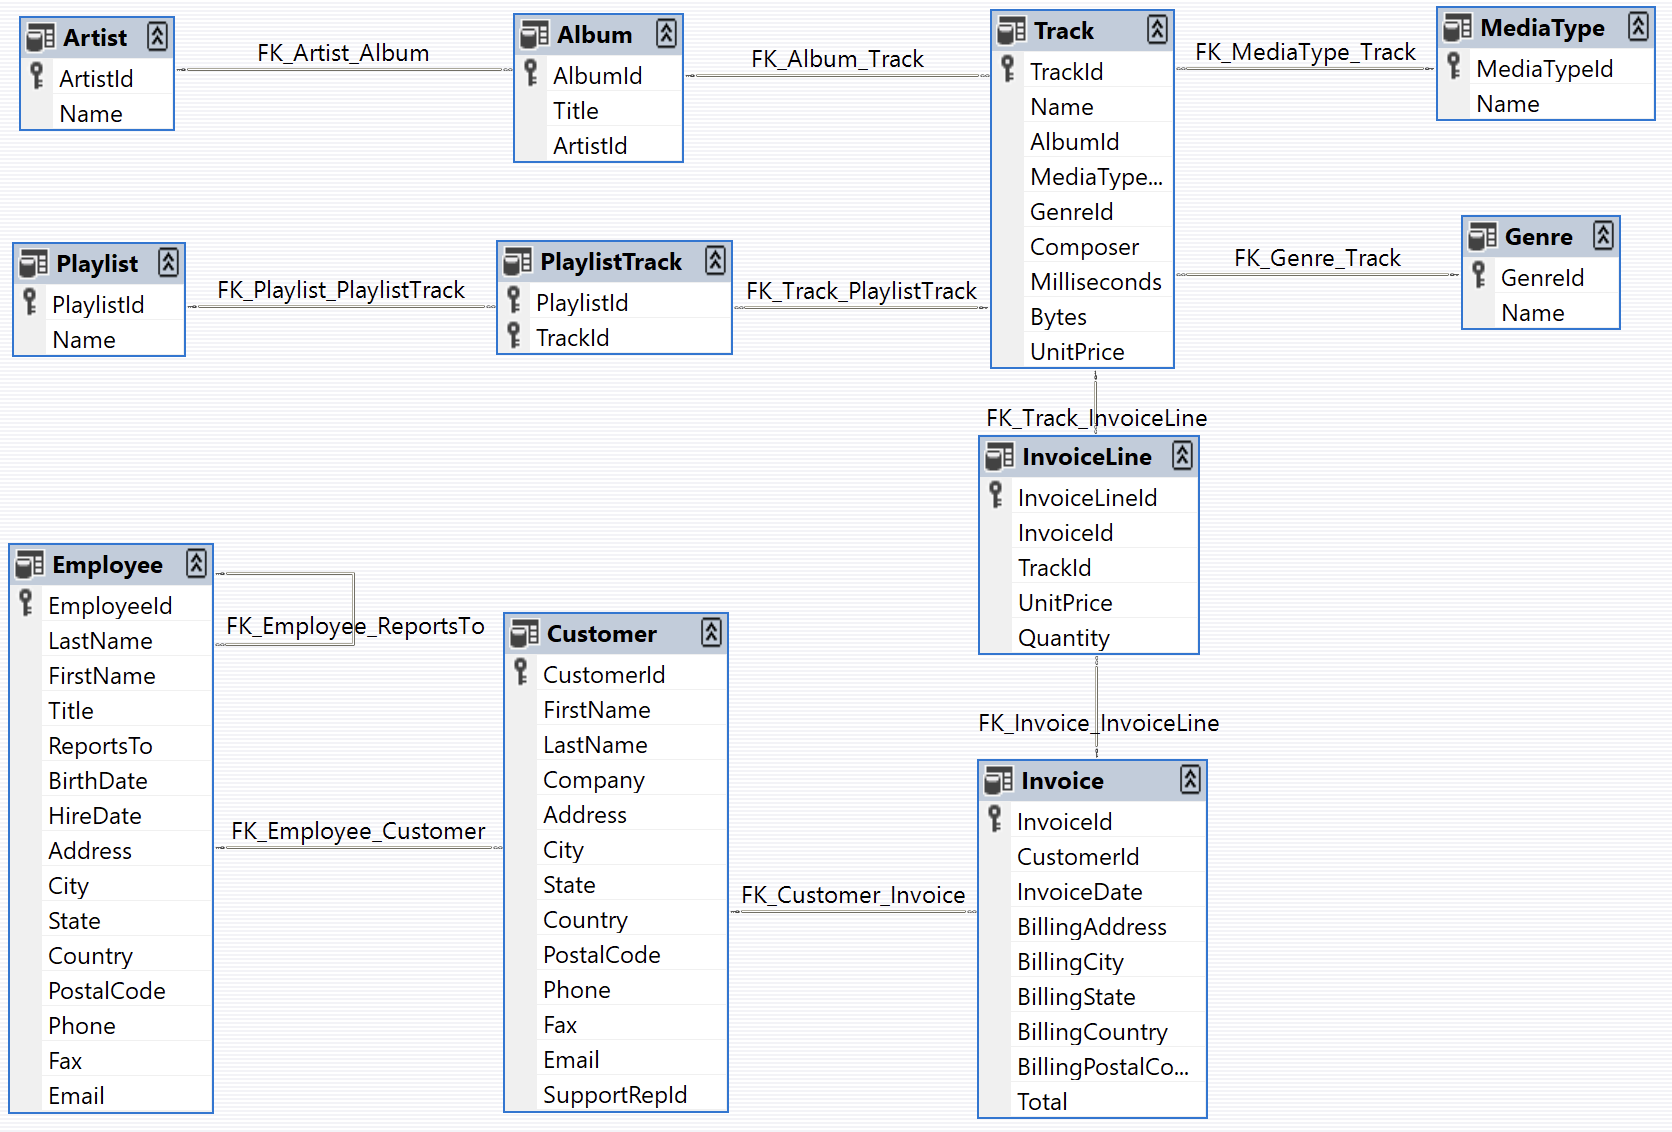

In [ ]:
import sqlite3
import pandas as pd

# Connect to the Chinook database
conn = sqlite3.connect('chinook.db')

# Quick check — list all tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables in Chinook:")
print(tables)

Tables in Chinook:
             name
0           Album
1          Artist
2        Customer
3        Employee
4           Genre
5         Invoice
6     InvoiceLine
7       MediaType
8        Playlist
9   PlaylistTrack
10          Track


In [ ]:
# Load tables we'll use for joins
artists = pd.read_sql("SELECT * FROM Artist", conn)
albums = pd.read_sql("SELECT * FROM Album", conn)
tracks = pd.read_sql("SELECT * FROM Track", conn)
genres = pd.read_sql("SELECT * FROM Genre", conn)
customers = pd.read_sql("SELECT * FROM Customer", conn)
invoices = pd.read_sql("SELECT * FROM Invoice", conn)
invoice_lines = pd.read_sql("SELECT * FROM InvoiceLine", conn)

print(f"Artists: {len(artists)} rows")
print(f"Albums: {len(albums)} rows")
print(f"Tracks: {len(tracks)} rows")
print(f"Genres: {len(genres)} rows")
print(f"Customers: {len(customers)} rows")
print(f"Invoices: {len(invoices)} rows")
print(f"InvoiceLines: {len(invoice_lines)} rows")

Artists: 275 rows
Albums: 347 rows
Tracks: 3503 rows
Genres: 25 rows
Customers: 59 rows
Invoices: 412 rows
InvoiceLines: 2240 rows


,AlbumId,Title,ArtistId
0,1,For Those About To Rock We Salute You,1
1,2,Balls to the Wall,2
2,3,Restless and Wild,2
3,4,Let There Be Rock,1
4,5,Big Ones,3
...,...,...,...
342,343,Respighi:Pines of Rome,226
343,344,Schubert: The Late String Quartets & String Qu...,272
344,345,Monteverdi: L'Orfeo,273
345,346,Mozart: Chamber Music,274


In [ ]:
tracks

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99
...,...,...,...,...,...,...,...,...,...
3498,3499,Pini Di Roma (Pinien Von Rom) \ I Pini Della V...,343,2,24,None,286741,4718950,0.99
3499,3500,"String Quartet No. 12 in C Minor, D. 703 ""Quar...",344,2,24,Franz Schubert,139200,2283131,0.99
3500,3501,"L'orfeo, Act 3, Sinfonia (Orchestra)",345,2,24,Claudio Monteverdi,66639,1189062,0.99
3501,3502,"Quintet for Horn, Violin, 2 Violas, and Cello ...",346,2,24,Wolfgang Amadeus Mozart,221331,3665114,0.99


In [ ]:
artists

,ArtistId,Name
0,1,AC/DC
1,2,Accept
2,3,Aerosmith
3,4,Alanis Morissette
4,5,Alice In Chains
...,...,...
270,271,"Mela Tenenbaum, Pro Musica Prague & Richard Kapp"
271,272,Emerson String Quartet
272,273,"C. Monteverdi, Nigel Rogers - Chiaroscuro; Lon..."
273,274,Nash Ensemble


In [ ]:
albums

,AlbumId,Title,ArtistId
0,1,For Those About To Rock We Salute You,1
1,2,Balls to the Wall,2
2,3,Restless and Wild,2
3,4,Let There Be Rock,1
4,5,Big Ones,3
...,...,...,...
342,343,Respighi:Pines of Rome,226
343,344,Schubert: The Late String Quartets & String Qu...,272
344,345,Monteverdi: L'Orfeo,273
345,346,Mozart: Chamber Music,274


In [ ]:
    name
0           Album
1          Artist
2        Customer
3        Employee
4           Genre
5         Invoice
6     InvoiceLine
7       MediaType
8        Playlist
9   PlaylistTrack
10          Track

In [ ]:
sql = ''' select * from Artist INNER JOIN Album on Artist.ArtistId = Album.ArtistId'''
tables2 = pd.read_sql(sql, conn)
tables2

,ArtistId,Name,AlbumId,Title,ArtistId
0,1,AC/DC,1,For Those About To Rock We Salute You,1
1,2,Accept,2,Balls to the Wall,2
2,2,Accept,3,Restless and Wild,2
3,1,AC/DC,4,Let There Be Rock,1
4,3,Aerosmith,5,Big Ones,3
...,...,...,...,...,...
342,226,Eugene Ormandy,343,Respighi:Pines of Rome,226
343,272,Emerson String Quartet,344,Schubert: The Late String Quartets & String Qu...,272
344,273,"C. Monteverdi, Nigel Rogers - Chiaroscuro; Lon...",345,Monteverdi: L'Orfeo,273
345,274,Nash Ensemble,346,Mozart: Chamber Music,274


In [ ]:
pd.merge(artists, albums, on= 'ArtistId', how='inner')

,ArtistId,Name,AlbumId,Title
0,1,AC/DC,1,For Those About To Rock We Salute You
1,1,AC/DC,4,Let There Be Rock
2,2,Accept,2,Balls to the Wall
3,2,Accept,3,Restless and Wild
4,3,Aerosmith,5,Big Ones
...,...,...,...,...
342,271,"Mela Tenenbaum, Pro Musica Prague & Richard Kapp",342,"Locatelli: Concertos for Violin, Strings and C..."
343,272,Emerson String Quartet,344,Schubert: The Late String Quartets & String Qu...
344,273,"C. Monteverdi, Nigel Rogers - Chiaroscuro; Lon...",345,Monteverdi: L'Orfeo
345,274,Nash Ensemble,346,Mozart: Chamber Music


In [ ]:
pd.merge(tracks,
          genres,
          on = 'GenreId',
          how = 'inner',
          suffixes = ("_track", "_genre"))


,TrackId,Name_track,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice,Name_genre
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99,Rock
1,2,Balls to the Wall,2,2,1,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",342562,5510424,0.99,Rock
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99,Rock
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99,Rock
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99,Rock
...,...,...,...,...,...,...,...,...,...,...
3498,3499,Pini Di Roma (Pinien Von Rom) \ I Pini Della V...,343,2,24,None,286741,4718950,0.99,Classical
3499,3500,"String Quartet No. 12 in C Minor, D. 703 ""Quar...",344,2,24,Franz Schubert,139200,2283131,0.99,Classical
3500,3501,"L'orfeo, Act 3, Sinfonia (Orchestra)",345,2,24,Claudio Monteverdi,66639,1189062,0.99,Classical
3501,3502,"Quintet for Horn, Violin, 2 Violas, and Cello ...",346,2,24,Wolfgang Amadeus Mozart,221331,3665114,0.99,Classical


In [ ]:
tracks.columns

Index(['TrackId', 'Name', 'AlbumId', 'MediaTypeId', 'GenreId', 'Composer',
       'Milliseconds', 'Bytes', 'UnitPrice'],
      dtype='object')

In [ ]:
df2 = pd.merge(tracks, albums, on = "AlbumId", how = 'inner',
          suffixes = ("_tracks", "_albums"))
df2

,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice,Title,ArtistId
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99,For Those About To Rock We Salute You,1
1,2,Balls to the Wall,2,2,1,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",342562,5510424,0.99,Balls to the Wall,2
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99,Restless and Wild,2
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99,Restless and Wild,2
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99,Restless and Wild,2
...,...,...,...,...,...,...,...,...,...,...,...
3498,3499,Pini Di Roma (Pinien Von Rom) \ I Pini Della V...,343,2,24,None,286741,4718950,0.99,Respighi:Pines of Rome,226
3499,3500,"String Quartet No. 12 in C Minor, D. 703 ""Quar...",344,2,24,Franz Schubert,139200,2283131,0.99,Schubert: The Late String Quartets & String Qu...,272
3500,3501,"L'orfeo, Act 3, Sinfonia (Orchestra)",345,2,24,Claudio Monteverdi,66639,1189062,0.99,Monteverdi: L'Orfeo,273
3501,3502,"Quintet for Horn, Violin, 2 Violas, and Cello ...",346,2,24,Wolfgang Amadeus Mozart,221331,3665114,0.99,Mozart: Chamber Music,274


In [ ]:
pd.merge(df2, genres, on = 'GenreId', how="inner",  suffixes = ("_df2", "_genre"))

,TrackId,Name_df2,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice,Title,ArtistId,Name_genre
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99,For Those About To Rock We Salute You,1,Rock
1,2,Balls to the Wall,2,2,1,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",342562,5510424,0.99,Balls to the Wall,2,Rock
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99,Restless and Wild,2,Rock
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99,Restless and Wild,2,Rock
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99,Restless and Wild,2,Rock
...,...,...,...,...,...,...,...,...,...,...,...,...
3498,3499,Pini Di Roma (Pinien Von Rom) \ I Pini Della V...,343,2,24,None,286741,4718950,0.99,Respighi:Pines of Rome,226,Classical
3499,3500,"String Quartet No. 12 in C Minor, D. 703 ""Quar...",344,2,24,Franz Schubert,139200,2283131,0.99,Schubert: The Late String Quartets & String Qu...,272,Classical
3500,3501,"L'orfeo, Act 3, Sinfonia (Orchestra)",345,2,24,Claudio Monteverdi,66639,1189062,0.99,Monteverdi: L'Orfeo,273,Classical
3501,3502,"Quintet for Horn, Violin, 2 Violas, and Cello ...",346,2,24,Wolfgang Amadeus Mozart,221331,3665114,0.99,Mozart: Chamber Music,274,Classical


In [ ]:
full_catalog = (
    tracks
    .merge(albums, on='AlbumId')
    .merge(artists, on='ArtistId')
    .merge(genres, on='GenreId', suffixes=('_artist', '_genre'))
)
full_catalog

,TrackId,Name_x,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice,Title,ArtistId,Name_y,Name
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99,For Those About To Rock We Salute You,1,AC/DC,Rock
1,2,Balls to the Wall,2,2,1,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",342562,5510424,0.99,Balls to the Wall,2,Accept,Rock
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99,Restless and Wild,2,Accept,Rock
3,4,Restless and Wild,3,2,1,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D...",252051,4331779,0.99,Restless and Wild,2,Accept,Rock
4,5,Princess of the Dawn,3,2,1,Deaffy & R.A. Smith-Diesel,375418,6290521,0.99,Restless and Wild,2,Accept,Rock
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3498,3499,Pini Di Roma (Pinien Von Rom) \ I Pini Della V...,343,2,24,None,286741,4718950,0.99,Respighi:Pines of Rome,226,Eugene Ormandy,Classical
3499,3500,"String Quartet No. 12 in C Minor, D. 703 ""Quar...",344,2,24,Franz Schubert,139200,2283131,0.99,Schubert: The Late String Quartets & String Qu...,272,Emerson String Quartet,Classical
3500,3501,"L'orfeo, Act 3, Sinfonia (Orchestra)",345,2,24,Claudio Monteverdi,66639,1189062,0.99,Monteverdi: L'Orfeo,273,"C. Monteverdi, Nigel Rogers - Chiaroscuro; Lon...",Classical
3501,3502,"Quintet for Horn, Violin, 2 Violas, and Cello ...",346,2,24,Wolfgang Amadeus Mozart,221331,3665114,0.99,Mozart: Chamber Music,274,Nash Ensemble,Classical


# Which artists have no albums

In [ ]:
query = '''select Artist.ArtistId, Artist.Name from
        Artist Left Join Album on Artist.ArtistId = Album.ArtistId
        where Album.AlbumId is NULL'''

df3 = pd.read_sql(query, conn)
df3

,ArtistId,Name
0,25,Milton Nascimento & Bebeto
1,26,Azymuth
2,28,João Gilberto
3,29,Bebel Gilberto
4,30,Jorge Vercilo
...,...,...
66,192,DJ Dolores & Orchestra Santa Massa
67,193,Seu Jorge
68,194,Sabotage E Instituto
69,195,Stereo Maracana


In [ ]:
artists_albums = pd.merge(artists, albums, on='ArtistId', how='left')

# Find artists with no albums (NaN in AlbumId)
no_albums = artists_albums[artists_albums['AlbumId'].isna()]
no_albums

,ArtistId,Name,AlbumId,Title
50,25,Milton Nascimento & Bebeto,NaN,NaN
51,26,Azymuth,NaN,NaN
55,28,João Gilberto,NaN,NaN
56,29,Bebel Gilberto,NaN,NaN
57,30,Jorge Vercilo,NaN,NaN
...,...,...,...,...
327,192,DJ Dolores & Orchestra Santa Massa,NaN,NaN
328,193,Seu Jorge,NaN,NaN
329,194,Sabotage E Instituto,NaN,NaN
330,195,Stereo Maracana,NaN,NaN


# Which tracks are never purchased at all

In [ ]:
invoice_lines

,InvoiceLineId,InvoiceId,TrackId,UnitPrice,Quantity
0,1,1,2,0.99,1
1,2,1,4,0.99,1
2,3,2,6,0.99,1
3,4,2,8,0.99,1
4,5,2,10,0.99,1
...,...,...,...,...,...
2235,2236,411,3136,0.99,1
2236,2237,411,3145,0.99,1
2237,2238,411,3154,0.99,1
2238,2239,411,3163,0.99,1


In [ ]:
track_sales = pd.merge(invoice_lines, tracks, on = "TrackId",
         how = "right")
track_sales[track_sales['InvoiceLineId'].isna()]['TrackId']

,TrackId
7,7
13,11
19,17
20,18
25,22
...,...
3751,3497
3752,3498
3756,3501
3757,3502


In [ ]:
invoices

,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,1,2,2021-01-01 00:00:00,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,1.98
1,2,4,2021-01-02 00:00:00,Ullevålsveien 14,Oslo,None,Norway,0171,3.96
2,3,8,2021-01-03 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,5.94
3,4,14,2021-01-06 00:00:00,8210 111 ST NW,Edmonton,AB,Canada,T6G 2C7,8.91
4,5,23,2021-01-11 00:00:00,69 Salem Street,Boston,MA,USA,2113,13.86
...,...,...,...,...,...,...,...,...,...
407,408,25,2025-12-05 00:00:00,319 N. Frances Street,Madison,WI,USA,53703,3.96
408,409,29,2025-12-06 00:00:00,796 Dundas Street West,Toronto,ON,Canada,M6J 1V1,5.94
409,410,35,2025-12-09 00:00:00,"Rua dos Campeões Europeus de Viena, 4350",Porto,None,Portugal,None,8.91
410,411,44,2025-12-14 00:00:00,Porthaninkatu 9,Helsinki,None,Finland,00530,13.86


In [ ]:
which emploees have no customers assigend at all ( i need to print employee ful name)